<a href="https://colab.research.google.com/github/sruthisami/os/blob/main/DiskScheduling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 23, 89, 109, 45, 67, 124, 38, 59, 91, 166, 192, 163]
Total head movement: 547


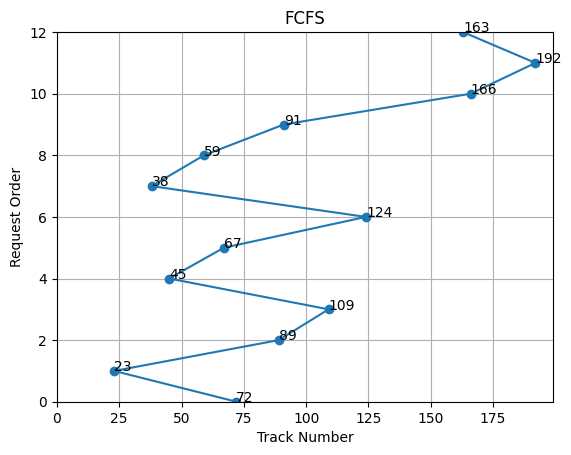


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 67, 59, 45, 38, 23, 89, 91, 109, 124, 163, 166, 192]
Total head movement: 218


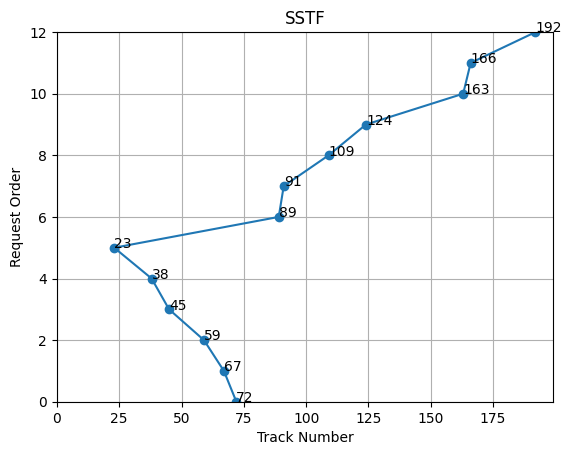


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 67, 59, 45, 38, 23, 0, 89, 91, 109, 124, 163, 166, 192]
Total head movement: 264


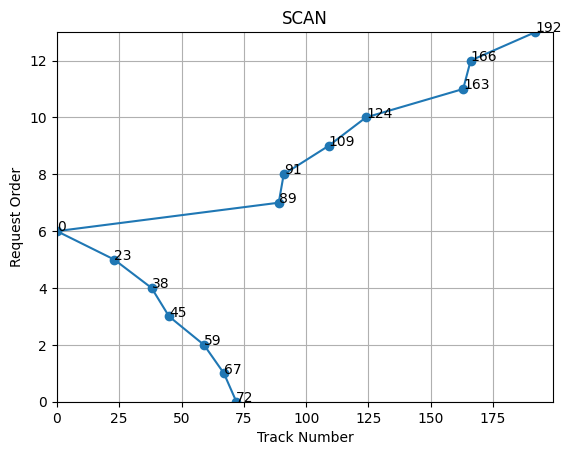


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 67, 59, 45, 38, 23, 0, 199, 192, 166, 163, 124, 109, 91, 89]
Total head movement: 381


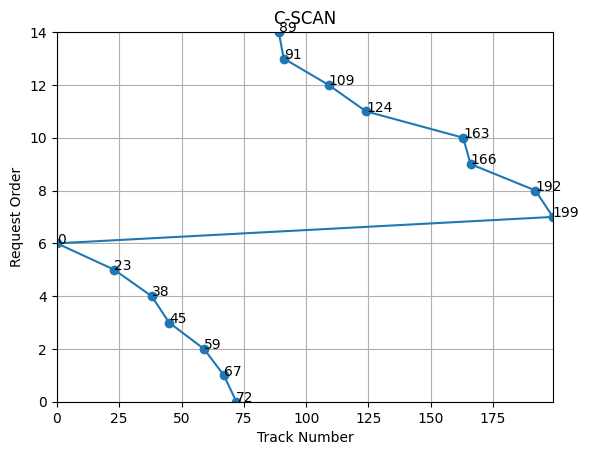


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 67, 59, 45, 38, 23, 89, 91, 109, 124, 163, 166, 192]
Total head movement: 218


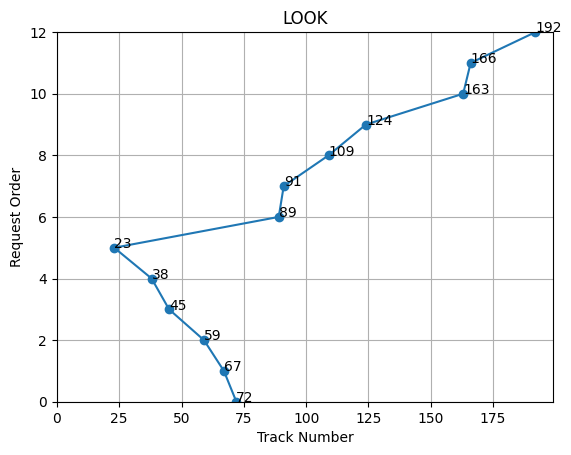


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit

Sequence: [72, 67, 59, 45, 38, 23, 192, 166, 163, 124, 109, 91, 89]
Total head movement: 321


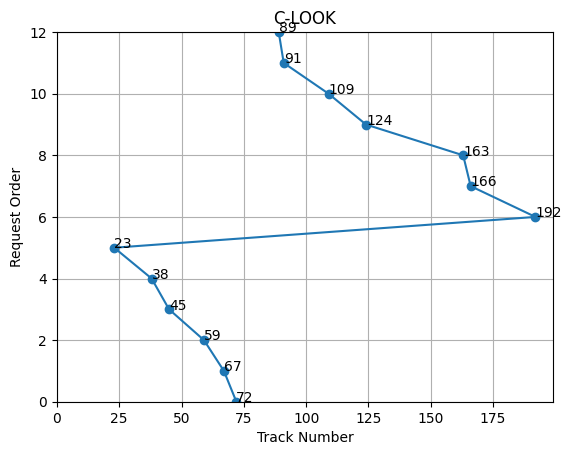


Disk Scheduling Menu
1 FCFS
2 SSTF
3 SCAN
4 C-SCAN
5 LOOK
6 C-LOOK
7 Exit
Enter choice: 7


In [ ]:
import matplotlib.pyplot as plt


def plot_graph(seq, title, disk_min, disk_max):
    order = list(range(len(seq)))

    plt.figure()
    plt.plot(seq, order, marker='o')

    # label each point
    # for i in range(len(seq)):
    #     plt.text(seq[i], order[i], str(seq[i]))

    plt.xlabel("Track Number")
    plt.ylabel("Request Order")
    plt.title(title)

    plt.xlim(disk_min, disk_max)
    plt.ylim(0, len(seq)-1)

    plt.grid(True)
    plt.show()


def fcfs(req, head, disk_min, disk_max):
    sequence = [head] + req
    movement = sum(abs(sequence[i+1] - sequence[i]) for i in range(len(sequence)-1))

    print("\nSequence:", sequence)
    print("Total head movement:", movement)

    plot_graph(sequence, "FCFS", disk_min, disk_max)


def sstf(req, head, disk_min, disk_max):
    requests = req.copy()
    sequence = [head]
    movement = 0
    current = head

    while requests:
    closest = requests[0]
    min_distance = abs(current - closest)

    for r in requests:
        distance = abs(current - r)
        if distance < min_distance:
            min_distance = distance
            closest = r

    movement += abs(current - closest)
    current = closest
    sequence.append(current)
    requests.remove(closest)

    print("\nSequence:", sequence)
    print("Total head movement:", movement)

    plot_graph(sequence, "SSTF", disk_min, disk_max)


def scan(req, head, direction, disk_min, disk_max):
    left = []
    right = []

    for r in req:
        if r < head:
            left.append(r)
        else:
            right.append(r)

    left.sort()
    right.sort()

    if direction == "left":
        sequence = [head] + left[::-1] + [disk_min] + right
    else:
        sequence = [head] + right + [disk_max] + left[::-1]

movement = 0
for i in range(len(sequence) - 1):
    movement += abs(sequence[i+1] - sequence[i])

print("\nSequence:", sequence)
print("Total head movement:", movement)

plot_graph(sequence, "SCAN", disk_min, disk_max)


def cscan(req, head, direction, disk_min, disk_max):
    left = sorted([r for r in req if r < head])
    right = sorted([r for r in req if r >= head])

    if direction == "right":
        sequence = [head] + right + [disk_max, disk_min] + left
    else:
        sequence = [head] + left[::-1] + [disk_min, disk_max] + right[::-1]

    movement = sum(abs(sequence[i+1] - sequence[i]) for i in range(len(sequence)-1))

    print("\nSequence:", sequence)
    print("Total head movement:", movement)

    plot_graph(sequence, "C-SCAN", disk_min, disk_max)


def look(req, head, direction, disk_min, disk_max):
    left = sorted([r for r in req if r < head])
    right = sorted([r for r in req if r >= head])

    if direction == "left":
        sequence = [head] + left[::-1] + right
    else:
        sequence = [head] + right + left[::-1]

    movement = sum(abs(sequence[i+1] - sequence[i]) for i in range(len(sequence)-1))

    print("\nSequence:", sequence)
    print("Total head movement:", movement)

    plot_graph(sequence, "LOOK", disk_min, disk_max)


def clook(req, head, direction, disk_min, disk_max):
    left = sorted([r for r in req if r < head])
    right = sorted([r for r in req if r >= head])

    if direction == "right":
        sequence = [head] + right + left
    else:
        sequence = [head] + left[::-1] + right[::-1]

    movement = sum(abs(sequence[i+1] - sequence[i]) for i in range(len(sequence)-1))

    print("\nSequence:", sequence)
    print("Total head movement:", movement)

    plot_graph(sequence, "C-LOOK", disk_min, disk_max)


# ----------- MAIN -----------

disk_min = int(input("Enter minimum disk range: "))
disk_max = int(input("Enter maximum disk range: "))

requests = list(map(int, input("Enter disk requests: ").split()))
head = int(input("Enter initial head position: "))

while True:

    print("\nDisk Scheduling Menu")
    print("1 FCFS")
    print("2 SSTF")
    print("3 SCAN")
    print("4 C-SCAN")
    print("5 LOOK")
    print("6 C-LOOK")
    print("7 Exit")

    choice = int(input("Enter choice: "))

    if choice == 1:
        fcfs(requests, head, disk_min, disk_max)

    elif choice == 2:
        sstf(requests, head, disk_min, disk_max)

    elif choice in [3, 4, 5, 6]:
        direction = input("Enter direction (left/right): ").lower()

        if direction not in ["left", "right"]:
            print("Invalid direction!")
            continue

        if choice == 3:
            scan(requests, head, direction, disk_min, disk_max)
        elif choice == 4:
            cscan(requests, head, direction, disk_min, disk_max)
        elif choice == 5:
            look(requests, head, direction, disk_min, disk_max)
        elif choice == 6:
            clook(requests, head, direction, disk_min, disk_max)

    elif choice == 7:
        break

    else:
        print("Invalid choice")